# Bank GoodCredit — Credit Risk Prediction
### Data Science Project PR-0015

**Objective:** Predict `Bad_label` for current credit-card customers and evaluate the model using Gini and decile rank ordering.

The project contains:
- `Cust_Account`: historical accounts and payment information
- `Cust_Enquiry`: historical enquiry information
- `Cust_Demographics`: customer/application features and `Bad_label`

**Target:** `Bad_label`
- `0` = Good credit history
- `1` = Bad credit history / 30+ DPD bucket

**Benchmark:** Gini = 37.9

> This notebook deliberately does not embed the database password from the project document. Enter credentials through environment variables or the configuration cell.

## 1. Install packages

In [1]:
# Run once if packages are not already installed.
# !pip install pandas numpy sqlalchemy pymysql scikit-learn xgboost matplotlib seaborn openpyxl

## 2. Imports and display settings

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, text

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    accuracy_score
)

from xgboost import XGBClassifier

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42
TARGET = "bad_label"
CUSTOMER_ID = "customer_no"
BENCHMARK_GINI = 37.9

print("Libraries loaded.")

Libraries loaded.


## 3. Database configuration

Set the values below locally, or preferably use environment variables.

In [3]:
# Preferred: set these as environment variables before starting Jupyter.
# Example on Windows PowerShell:
#   $env:DB_HOST="..."
#   $env:DB_USER="..."
#   $env:DB_PASSWORD="..."
#
# Or enter them directly below for local/private use.

DB_HOST = os.getenv("DB_HOST", "18.136.157.135")
DB_PORT = os.getenv("DB_PORT", "3306")
DB_USER = os.getenv("DB_USER", "dm_team1")
DB_PASSWORD = os.getenv("DB_PASSWORD", "DM!$Team&279@20!")
DB_NAME = os.getenv("DB_NAME", "project_banking")

if "YOUR_" in DB_HOST or "YOUR_" in DB_USER or "YOUR_" in DB_PASSWORD:
    print("ACTION REQUIRED: set DB_HOST, DB_USER and DB_PASSWORD before loading data.")
else:
    print("Database configuration found.")

Database configuration found.


## 4. Connect to MySQL

In [4]:
from urllib.parse import quote_plus

connection_string = (
    f"mysql+pymysql://{DB_USER}:{quote_plus(DB_PASSWORD)}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

engine = create_engine(
    connection_string,
    pool_pre_ping=True
)

with engine.connect() as conn:
    conn.execute(text("SELECT 1"))

print("Database connection successful.")

Database connection successful.


## 5. Load source tables

In [5]:
ACCOUNT_TABLE = "Cust_Account"
ENQUIRY_TABLE = "Cust_Enquiry"
DEMOGRAPHICS_TABLE = "Cust_Demographics"

account = pd.read_sql(f"SELECT * FROM {ACCOUNT_TABLE}", engine)
enquiry = pd.read_sql(f"SELECT * FROM {ENQUIRY_TABLE}", engine)
demographics = pd.read_sql(f"SELECT * FROM {DEMOGRAPHICS_TABLE}", engine)

print("Account:", account.shape)
print("Enquiry:", enquiry.shape)
print("Demographics:", demographics.shape)

Account: (186329, 21)
Enquiry: (413188, 6)
Demographics: (23896, 83)


## 6. Inspect source data

In [6]:
print("ACCOUNT COLUMNS")
print(account.columns.tolist())

print("\nENQUIRY COLUMNS")
print(enquiry.columns.tolist())

print("\nDEMOGRAPHICS COLUMNS")
print(demographics.columns.tolist())

display(account.head())
display(enquiry.head())
display(demographics.head())

ACCOUNT COLUMNS
['dt_opened', 'customer_no', 'upload_dt', 'acct_type', 'owner_indic', 'opened_dt', 'last_paymt_dt', 'closed_dt', 'reporting_dt', 'high_credit_amt', 'cur_balance_amt', 'amt_past_due', 'paymenthistory1', 'paymenthistory2', 'paymt_str_dt', 'paymt_end_dt', 'creditlimit', 'cashlimit', 'rateofinterest', 'paymentfrequency', 'actualpaymentamount']

ENQUIRY COLUMNS
['dt_opened', 'customer_no', 'upload_dt', 'enquiry_dt', 'enq_purpose', 'enq_amt']

DEMOGRAPHICS COLUMNS
['dt_opened', 'customer_no', 'entry_time', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35

,dt_opened,customer_no,upload_dt,acct_type,owner_indic,opened_dt,last_paymt_dt,closed_dt,reporting_dt,high_credit_amt,cur_balance_amt,amt_past_due,paymenthistory1,paymenthistory2,paymt_str_dt,paymt_end_dt,creditlimit,cashlimit,rateofinterest,paymentfrequency,actualpaymentamount
0,10-Nov-15,12265,20-Oct-15,6,1,09-Jun-13,30-Jun-14,05-Jul-14,30-Sep-15,20900,0,,"""""""STDSTDSTDXXXXXXXXXXXXXXXSTDXXXXXXXXXXXXXXXS...",,01-Sep-15,01-Jul-14,,,,,
1,10-Nov-15,12265,20-Oct-15,10,1,25-May-12,06-Sep-15,,03-Oct-15,16201,10390,,"""""""0000000000000000000000000000000000000000000...","""""""000000000000000000000000000XXX0000000000000...",01-Oct-15,01-Nov-12,14000,1400,,3,5603
2,10-Nov-15,12265,20-Oct-15,10,1,22-Mar-12,31-Aug-15,,30-Sep-15,41028,34420,,"""""""0000000000000000000000000000000000000000000...","""""""0000000000000000000000000000000000000000000...",01-Sep-15,01-Oct-12,,,,,
3,20-Jul-15,15606,09-Jul-15,10,1,13-Jan-06,,26-Jul-07,31-Jan-09,93473,0,,"""""""1200900600600600300000000000000000000000000...",,01-Jul-07,01-Feb-06,,,,,
4,20-Jul-15,15606,09-Jul-15,6,1,18-Jan-15,05-May-15,,31-May-15,20250,13500,,"""""""000000000000000""""""",,01-May-15,01-Jan-15,,,,,


,dt_opened,customer_no,upload_dt,enquiry_dt,enq_purpose,enq_amt
0,18-Apr-15,1,21-Apr-15,19-Dec-14,2,3500000
1,18-Apr-15,1,21-Apr-15,05-Mar-14,5,500000
2,18-Apr-15,1,21-Apr-15,05-Mar-14,0,50000
3,18-Apr-15,1,21-Apr-15,22-Feb-14,10,50000
4,18-Apr-15,1,21-Apr-15,11-Jun-13,10,1000


,dt_opened,customer_no,entry_time,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,Bad_label
0,18-Apr-15,1,13-Apr-15,Insignia,13-Apr-15,650,2,Card Setup,14,500000,,,,Y,IS1,,0,159,4284,4284,,1,ADFPNXXXXX,03-Sep-65,98332XXXXX,N,@REDIFFMAIL.COM,1,2,,Mumbai / Navi Mumbai / Thane,400610,1965,0,Self,Y,2,90000,,,,0,0,0,0,Mumbai,400059,@CODOGNOTTO.NET,PAN Card,ADFPNXXXXX,The Ratnakar Bank Ltd.,,Y,State Bank of India,0,01-Jun-13,17-Jun-16,1,21,,Y,Y,N,,Y,1965-0,21,15,400610,0,2,90000,Nov-00,21,R,,,0000-00-00,0,98332XXXXX,1,N,0
1,21-Apr-15,2,21-Apr-15,Insignia,21-Apr-15,760,1,Card Setup,14,1200000,,,,Y,IS1,,0,91,B001,4077,,1,AJWPRXXXXX,14-Jul-62,99455XXXXX,N,@GMAIL.COM,1,2,,Bengaluru,560042,1969,0,Self,Y,2,1,,,,0,0,0,0,Bangalore,560042,,PAN Card,AJWPRXXXXX,The Ratnakar Bank Ltd.,,N,,0,,17-Jun-16,1,17,,Y,Y,N,,Y,1969-0,17,12,560042,0,2,1,Nov-00,17,R,,,0000-00-00,0,99455XXXXX,1,N,0
2,22-Apr-15,3,21-Apr-15,Insignia,21-Apr-15,774,1,Card Setup,14,700000,,,,Y,IS1,,0,91,B001,4077,,2,AFAPNXXXXX,10-Apr-66,98456XXXXX,N,@SHOBANARAYAN.COM,1,0,,Bengaluru,560042,1966,0,Self,Y,2,1,,,,0,0,0,0,Bangalore,560042,,PAN Card,AFAPNXXXXX,,,N,,0,,17-Jun-16,3,17,,N,Y,N,,Y,1966-0,17,12,560042,0,2,1,Nov-00,17,R,,,0000-00-00,0,98456XXXXX,1,N,0
3,25-Apr-15,4,15-Apr-15,Insignia,20-Apr-15,770,1,Card Setup,14,500000,,,,Y,IS1,,0,157,5107,5107,,1,AAAPDXXXXX,16-Apr-64,98220XXXXX,N,@VSNL.COM,1,3,,Pune,411001,1988,0,Self,Y,2,100000,,,,0,0,0,0,Pune,411026,@ALBAJ.COM,PAN Card,AAAPDXXXXX,The Ratnakar Bank Ltd.,,Y,HDFC Bank,0,,17-Jun-16,1,21,,Y,Y,N,,Y,1988-0,21,16,411001,0,2,100000,Nov-00,21,R,,,6/15/65,1,98220XXXXX,1,N,0
4,06-May-15,5,30-Apr-15,Insignia,,,3,Card Setup,14,500000,,,,Y,IS1,,0,100,D016,4564,,1,ABEPSXXXXX,03-Jan-54,98111XXXXX,N,@REDIFFMAIL.COM,1,3,,Gurgaon,122009,1995,0,Self,Y,2,300000,,,,0,0,0,0,Gurgaon,122009,,PAN Card,ABEPSXXXXX,The Ratnakar Bank Ltd.,,N,,0,,17-Jun-16,1,13,,Y,Y,N,,Y,1995-0,13,3,122009,0,2,300000,Nov-00,13,R,,,0000-00-00,0,98111XXXXX,1,N,0


## 7. Standardize column names

This cell handles common spacing/case variations without changing the project's business meaning.

In [7]:
def standardize_columns(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )
    return df

account = standardize_columns(account)
enquiry = standardize_columns(enquiry)
demographics = standardize_columns(demographics)

# Common ID normalization
for df in [account, enquiry, demographics]:
    if "customer_no" not in df.columns and "customer" in df.columns:
        df.rename(columns={"customer": "customer_no"}, inplace=True)

print("Account ID present:", "customer_no" in account.columns)
print("Enquiry ID present:", "customer_no" in enquiry.columns)
print("Demographics ID present:", "customer_no" in demographics.columns)

Account ID present: True
Enquiry ID present: True
Demographics ID present: True


## 8. Basic data-quality report

In [8]:
def data_quality_report(df):
    return (
        pd.DataFrame({
            "dtype": df.dtypes.astype(str),
            "missing_count": df.isna().sum(),
            "missing_pct": (df.isna().mean() * 100).round(2),
            "unique_values": df.nunique(dropna=True)
        })
        .sort_values(["missing_pct", "unique_values"], ascending=[False, True])
    )

display(data_quality_report(account).head(30))
display(data_quality_report(enquiry).head(30))
display(data_quality_report(demographics).head(30))

,dtype,missing_count,missing_pct,unique_values
paymentfrequency,object,0,0.0,3
owner_indic,object,0,0.0,4
acct_type,object,0,0.0,31
upload_dt,object,0,0.0,75
dt_opened,object,0,0.0,197
paymt_str_dt,object,0,0.0,234
paymt_end_dt,object,0,0.0,235
amt_past_due,object,0,0.0,630
creditlimit,object,0,0.0,1380
cashlimit,object,0,0.0,1456


,dtype,missing_count,missing_pct,unique_values
enq_purpose,object,0,0.0,37
upload_dt,object,0,0.0,76
dt_opened,object,0,0.0,197
enquiry_dt,object,0,0.0,3772
enq_amt,object,0,0.0,7384
customer_no,object,0,0.0,23896


,dtype,missing_count,missing_pct,unique_values
feature_5,object,0,0.0,2
feature_6,object,0,0.0,2
feature_54,object,0,0.0,2
bad_label,object,0,0.0,2
feature_11,object,0,0.0,3
feature_14,object,0,0.0,3
feature_19,object,0,0.0,3
feature_23,object,0,0.0,3
feature_25,object,0,0.0,3
feature_33,object,0,0.0,3


## 9. Target validation and distribution

bad_label
0    22892
1     1004
Name: count, dtype: int64

Target percentage:
bad_label
0    95.8
1     4.2
Name: proportion, dtype: float64


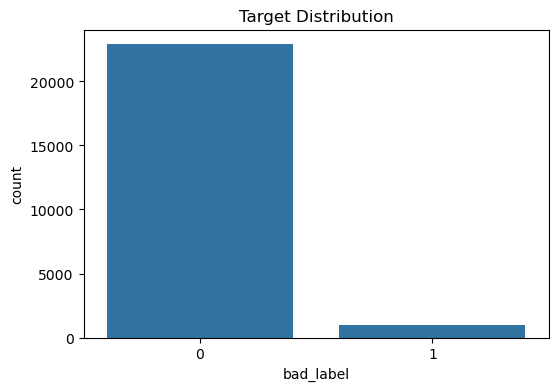

In [9]:
assert TARGET in demographics.columns, (
    f"{TARGET} was not found in demographics. "
    f"Available columns: {demographics.columns.tolist()}"
)

print(demographics[TARGET].value_counts(dropna=False))
print("\nTarget percentage:")
print((demographics[TARGET].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(6,4))
sns.countplot(data=demographics, x=TARGET)
plt.title("Target Distribution")
plt.show()

## 10. Convert date columns

In [10]:
account_date_columns = [
    "dt_opened", "upload_dt", "opened_dt", "last_paymt_dt",
    "closed_dt", "reporting_dt", "paymt_str_dt", "paymt_end_dt"
]

for col in account_date_columns:
    if col in account.columns:
        account[col] = pd.to_datetime(account[col], errors="coerce")

enquiry_date_columns = ["dt_opened", "upload_dt", "enquiry_dt"]

for col in enquiry_date_columns:
    if col in enquiry.columns:
        enquiry[col] = pd.to_datetime(enquiry[col], errors="coerce")

if "entry_time" in demographics.columns:
    demographics["entry_time"] = pd.to_datetime(
        demographics["entry_time"], errors="coerce"
    )

## 11. Account-level feature engineering

In [11]:
def build_account_features(account):
    a = account.copy()

    required_numeric = [
        "high_credit_amt", "cur_balance_amt", "amt_past_due",
        "creditlimit", "cashlimit", "rateofinterest",
        "actualpaymentamount"
    ]

    for col in required_numeric:
        if col in a.columns:
            a[col] = pd.to_numeric(a[col], errors="coerce")

    grouped = a.groupby(CUSTOMER_ID)

    agg_map = {}
    for col, funcs in {
        "high_credit_amt": ["sum", "mean", "max"],
        "cur_balance_amt": ["sum", "mean", "max"],
        "amt_past_due": ["sum", "mean", "max"],
        "creditlimit": ["sum", "mean", "max"],
        "cashlimit": ["sum", "mean", "max"],
        "rateofinterest": ["mean", "max"],
        "actualpaymentamount": ["sum", "mean", "max"]
    }.items():
        if col in a.columns:
            agg_map[col] = funcs

    out = grouped.agg(agg_map)
    out.columns = [
        f"{col}_{func}" for col, func in out.columns
    ]
    out = out.reset_index()

    out["count_accounts"] = grouped.size().values

    if "opened_dt" in a.columns and "last_paymt_dt" in a.columns:
        a["diff_lastpaymt_opened_dt"] = (
            a["last_paymt_dt"] - a["opened_dt"]
        ).dt.days

        date_agg = a.groupby(CUSTOMER_ID)["diff_lastpaymt_opened_dt"].agg(
            total_diff_lastpaymt_opened_dt="sum",
            mean_diff_lastpaymt_opened_dt="mean",
            min_diff_lastpaymt_opened_dt="min",
            max_diff_lastpaymt_opened_dt="max"
        ).reset_index()

        out = out.merge(date_agg, on=CUSTOMER_ID, how="left")

    # Credit utilization
    if {"cur_balance_amt", "creditlimit"}.issubset(a.columns):
        out["Ratio_currbalance_creditlimit"] = (
            out["cur_balance_amt_sum"] /
            out["creditlimit_sum"].replace(0, np.nan)
        )

    if {"cashlimit", "creditlimit"}.issubset(a.columns):
        out["cashlimit_to_creditlimit"] = (
            out["cashlimit_sum"] /
            out["creditlimit_sum"].replace(0, np.nan)
        )

    if {"amt_past_due", "cur_balance_amt"}.issubset(a.columns):
        out["past_due_to_balance_ratio"] = (
            out["amt_past_due_sum"] /
            out["cur_balance_amt_sum"].abs().replace(0, np.nan)
        )

        past_due_count = (
            a.assign(
                past_due_flag=(a["amt_past_due"] > 0).astype(int)
            )
            .groupby(CUSTOMER_ID)["past_due_flag"]
            .sum()
            .reset_index(name="count_past_due_accounts")
        )
        out = out.merge(past_due_count, on=CUSTOMER_ID, how="left")

    return out

account_features = build_account_features(account)

print(account_features.shape)
display(account_features.head())

(23896, 30)


,customer_no,high_credit_amt_sum,high_credit_amt_mean,high_credit_amt_max,cur_balance_amt_sum,cur_balance_amt_mean,cur_balance_amt_max,amt_past_due_sum,amt_past_due_mean,amt_past_due_max,creditlimit_sum,creditlimit_mean,creditlimit_max,cashlimit_sum,cashlimit_mean,cashlimit_max,rateofinterest_mean,rateofinterest_max,actualpaymentamount_sum,actualpaymentamount_mean,actualpaymentamount_max,count_accounts,total_diff_lastpaymt_opened_dt,mean_diff_lastpaymt_opened_dt,min_diff_lastpaymt_opened_dt,max_diff_lastpaymt_opened_dt,Ratio_currbalance_creditlimit,cashlimit_to_creditlimit,past_due_to_balance_ratio,count_past_due_accounts
0,1,7900063.0,526670.866667,2528846.0,4714857,261936.500000,2528846,2538209.0,1269104.5,2528846.0,670000.0,335000.000000,420000.0,168000.0,168000.0,168000.0,17.7108,34.585,71086.0,35543.0,45986.0,18,14960.0,1496.000000,336.0,3589.0,7.037100,0.250746,0.538343,2
1,10,8287800.0,828780.000000,5500000.0,247719,20643.250000,178725,0.0,NaN,NaN,405000.0,405000.000000,405000.0,243000.0,243000.0,243000.0,39.9600,39.960,200000.0,200000.0,200000.0,12,21912.0,1992.000000,271.0,4796.0,0.611652,0.600000,0.000000,0
2,100,954766.0,106085.111111,354122.0,434425,48269.444444,334609,0.0,NaN,NaN,187000.0,62333.333333,98000.0,27500.0,13750.0,17700.0,8.9000,8.900,5000.0,5000.0,5000.0,9,4070.0,508.750000,140.0,1022.0,2.323128,0.147059,0.000000,0
3,1000,1244266.0,414755.333333,548289.0,60462,20154.000000,31349,0.0,NaN,NaN,495000.0,247500.000000,270000.0,148500.0,74250.0,81000.0,NaN,NaN,23310.0,23310.0,23310.0,3,3628.0,1209.333333,917.0,1642.0,0.122145,0.300000,0.000000,0
4,10000,1139014.0,189835.666667,520000.0,1086158,181026.333333,582220,0.0,NaN,NaN,60000.0,60000.000000,60000.0,10000.0,10000.0,10000.0,20.9400,39.000,51500.0,51500.0,51500.0,6,524.0,131.000000,98.0,169.0,18.102633,0.166667,0.000000,0


## 12. Payment-history inspection

The project document suggests a payment-history feature, but it does not specify the encoding of `paymenthistory1`/`paymenthistory2`. Therefore this notebook inspects the values instead of assuming an encoding.

In [12]:
payment_cols = [
    c for c in ["paymenthistory1", "paymenthistory2"]
    if c in account.columns
]

for col in payment_cols:
    print(f"\n--- {col} ---")
    display(account[col].dropna().head(20))

print("\nDo not parse these fields until their actual encoding is confirmed.")


--- paymenthistory1 ---


0     """STDSTDSTDXXXXXXXXXXXXXXXSTDXXXXXXXXXXXXXXXS...
1     """0000000000000000000000000000000000000000000...
2     """0000000000000000000000000000000000000000000...
3     """1200900600600600300000000000000000000000000...
4                                 """000000000000000"""
5                                 """000000000000000"""
6                              """000000000000000000"""
7                        """000000000000000000000000"""
8     """0000000000000000000000000000000000000000000...
9     """000000000XXX000000000000030XXX0000000000000...
10    """0000000000000000000000000000000000000000000...
11    """0009009009009009009008888578297987677377066...
12                                            """000"""
13                                      """000017000"""
14                                            """XXX"""
15                                            """XXX"""
16    """XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX...
17                                            ""


--- paymenthistory2 ---


0                                                      
1     """000000000000000000000000000XXX0000000000000...
2     """0000000000000000000000000000000000000000000...
3                                                      
4                                                      
5                                                      
6                                                      
7                                                      
8            """000000000000000000000000000000000000"""
9     """030000000000XXX000000000000000000000000XXX0...
10    """0000000000000000000000000000000000000000000...
11    """553523492464433402372XXX3112802492191881581...
12                                                     
13                                                     
14                                                     
15                                                     
16    """XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXSTDSTDSTDSTDS...
17                                              


Do not parse these fields until their actual encoding is confirmed.


## 13. Enquiry-level feature engineering

In [13]:
def build_enquiry_features(enquiry, account):
    e = enquiry.copy()

    for col in ["enq_amt"]:
        if col in e.columns:
            e[col] = pd.to_numeric(e[col], errors="coerce")

    # Use each customer's latest enquiry as the reference date.
    if "enquiry_dt" in e.columns:
        ref = (
            e.groupby(CUSTOMER_ID)["enquiry_dt"]
            .max()
            .reset_index(name="reference_enquiry_date")
        )
        e = e.merge(ref, on=CUSTOMER_ID, how="left")

        e["days_since_enquiry"] = (
            e["reference_enquiry_date"] - e["enquiry_dt"]
        ).dt.days

    grouped = e.groupby(CUSTOMER_ID)

    agg = grouped.size().reset_index(name="count_total_enquiry")

    if "enq_amt" in e.columns:
        amount_agg = grouped["enq_amt"].agg(
            total_enquiry_amount="sum",
            mean_enquiry_amount="mean",
            max_enquiry_amount="max"
        ).reset_index()
        agg = agg.merge(amount_agg, on=CUSTOMER_ID, how="left")

    if "days_since_enquiry" in e.columns:
        for days, name in [
            (90, "count_enquiry_recency_90"),
            (365, "count_enquiry_recency_365")
        ]:
            temp = (
                e[e["days_since_enquiry"].between(0, days)]
                .groupby(CUSTOMER_ID)
                .size()
                .reset_index(name=name)
            )
            agg = agg.merge(temp, on=CUSTOMER_ID, how="left")

    if "enq_purpose" in e.columns:
        mode_purpose = (
            e.groupby(CUSTOMER_ID)["enq_purpose"]
            .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
            .reset_index(name="max_freq_enquiry")
        )
        agg = agg.merge(mode_purpose, on=CUSTOMER_ID, how="left")

    # Difference between first account opening and enquiry date
    if "opened_dt" in account.columns and "enquiry_dt" in e.columns:
        first_open = (
            account.groupby(CUSTOMER_ID)["opened_dt"]
            .min()
            .reset_index(name="first_account_opened_dt")
        )
        e = e.merge(first_open, on=CUSTOMER_ID, how="left")

        e["diff_open_enquiry_dt"] = (
            e["enquiry_dt"] - e["first_account_opened_dt"]
        ).dt.days

        date_agg = (
            e.groupby(CUSTOMER_ID)["diff_open_enquiry_dt"]
            .agg(
                mean_diff_open_enquiry_dt="mean",
                min_diff_open_enquiry_dt="min",
                max_diff_open_enquiry_dt="max"
            )
            .reset_index()
        )
        agg = agg.merge(date_agg, on=CUSTOMER_ID, how="left")

    return agg

enquiry_features = build_enquiry_features(enquiry, account)

print(enquiry_features.shape)
display(enquiry_features.head())

(23896, 11)


,customer_no,count_total_enquiry,total_enquiry_amount,mean_enquiry_amount,max_enquiry_amount,count_enquiry_recency_90,count_enquiry_recency_365,max_freq_enquiry,mean_diff_open_enquiry_dt,min_diff_open_enquiry_dt,max_diff_open_enquiry_dt
0,1,18,4981150.0,2.767306e+05,3500000.0,1.0,4.0,10,5432.500000,4359.0,6756.0
1,10,21,114492667.0,5.452032e+06,50000000.0,4.0,7.0,1,4675.428571,2551.0,5492.0
2,100,19,2467003.0,1.298423e+05,400000.0,6.0,10.0,5,1862.315789,861.0,2258.0
3,1000,10,193000.0,1.930000e+04,50000.0,2.0,4.0,10,595.500000,-6.0,1117.0
4,10000,14,1185750.0,8.469643e+04,300000.0,4.0,12.0,10,344.857143,-17.0,532.0


## 14. Merge customer-level features

In [14]:
customer_features = account_features.merge(
    enquiry_features,
    on=CUSTOMER_ID,
    how="outer"
)

model_data = demographics.merge(
    customer_features,
    on=CUSTOMER_ID,
    how="left"
)

print("Final modelling data:", model_data.shape)
display(model_data.head())

Final modelling data: (23896, 122)


,dt_opened,customer_no,entry_time,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,bad_label,high_credit_amt_sum,high_credit_amt_mean,high_credit_amt_max,cur_balance_amt_sum,cur_balance_amt_mean,cur_balance_amt_max,amt_past_due_sum,amt_past_due_mean,amt_past_due_max,creditlimit_sum,creditlimit_mean,creditlimit_max,cashlimit_sum,cashlimit_mean,cashlimit_max,rateofinterest_mean,rateofinterest_max,actualpaymentamount_sum,actualpaymentamount_mean,actualpaymentamount_max,count_accounts,total_diff_lastpaymt_opened_dt,mean_diff_lastpaymt_opened_dt,min_diff_lastpaymt_opened_dt,max_diff_lastpaymt_opened_dt,Ratio_currbalance_creditlimit,cashlimit_to_creditlimit,past_due_to_balance_ratio,count_past_due_accounts,count_total_enquiry,total_enquiry_amount,mean_enquiry_amount,max_enquiry_amount,count_enquiry_recency_90,count_enquiry_recency_365,max_freq_enquiry,mean_diff_open_enquiry_dt,min_diff_open_enquiry_dt,max_diff_open_enquiry_dt
0,18-Apr-15,1,2015-04-13,Insignia,13-Apr-15,650,2,Card Setup,14,500000,,,,Y,IS1,,0,159,4284,4284,,1,ADFPNXXXXX,03-Sep-65,98332XXXXX,N,@REDIFFMAIL.COM,1,2,,Mumbai / Navi Mumbai / Thane,400610,1965,0,Self,Y,2,90000,,,,0,0,0,0,Mumbai,400059,@CODOGNOTTO.NET,PAN Card,ADFPNXXXXX,The Ratnakar Bank Ltd.,,Y,State Bank of India,0,01-Jun-13,17-Jun-16,1,21,,Y,Y,N,,Y,1965-0,21,15,400610,0,2,90000,Nov-00,21,R,,,0000-00-00,0,98332XXXXX,1,N,0,7900063.0,5.266709e+05,2528846.0,4714857,261936.500000,2528846,2538209.0,1269104.5,2528846.0,670000.0,335000.000000,420000.0,168000.0,168000.000000,168000.0,17.7108,34.585,71086.0,35543.0,45986.0,18,14960.0,1496.000000,336.0,3589.0,7.037100,0.250746,0.538343,2,18,4.981150e+06,2.767306e+05,3500000.0,1.0,4.0,10,5432.500000,4359.0,6756.0
1,21-Apr-15,2,2015-04-21,Insignia,21-Apr-15,760,1,Card Setup,14,1200000,,,,Y,IS1,,0,91,B001,4077,,1,AJWPRXXXXX,14-Jul-62,99455XXXXX,N,@GMAIL.COM,1,2,,Bengaluru,560042,1969,0,Self,Y,2,1,,,,0,0,0,0,Bangalore,560042,,PAN Card,AJWPRXXXXX,The Ratnakar Bank Ltd.,,N,,0,,17-Jun-16,1,17,,Y,Y,N,,Y,1969-0,17,12,560042,0,2,1,Nov-00,17,R,,,0000-00-00,0,99455XXXXX,1,N,0,1117595.0,5.587975e+05,1000000.0,30754,15377.000000,24007,0.0,NaN,NaN,1000000.0,1000000.000000,1000000.0,1.0,1.000000,1.0,NaN,NaN,0.0,NaN,NaN,2,4070.0,2035.000000,2027.0,2043.0,0.030754,0.000001,0.000000,0,68,6.676682e+09,9.818650e+07,750000000.0,5.0,23.0,51,1273.514706,-977.0,2017.0
2,22-Apr-15,3,2015-04-21,Insignia,21-Apr-15,774,1,Card Setup,14,700000,,,,Y,IS1,,0,91,B001,4077,,2,AFAPNXXXXX,10-Apr-66,98456XXXXX,N,@SHOBANARAYAN.COM,1,0,,Bengaluru,560042,1966,0,Self,Y,2,1,,,,0,0,0,0,Bangalore,560042,,PAN Card,AFAPNXXXXX,,,N,,0,,17-Jun-16,3,17,,N,Y,N,,Y,1966-0,17,12,560042,0,2,1,Nov-00,17,R,,,0000-00-00,0,98456XXXXX,1,N,0,121523.0,1.215230e+05,121523.0,17864,17864.000000,17864,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,1,2454.0,2454.000000,2454.0,2454.0,NaN,NaN,0.000000,0,1,3.400000e+06,3.400000e+06,3400000.0,1.0,1.0,1,2045.000000,2045.0,2045.0
3,25-Apr-15,4,2015-04-15,Insignia,20-Apr-15,770,1,Card Setup,14,500000,,,,Y,IS1,,0,157,5107,5107,,1,AAAPDXXXXX,16-Apr-64,98220XXXXX,N,@VSNL.COM,1,3,,Pune,411001,1988,0,Self,Y,2,100000,,,,0,0,0,0,Pune,411026,@ALBAJ.COM,PAN Card,AAAPDXXXXX,The Ratnakar Bank Ltd.

## 15. Feature-engineering summary

In [15]:
feature_summary = pd.DataFrame({
    "feature": model_data.columns,
    "dtype": model_data.dtypes.astype(str).values,
    "missing_pct": (model_data.isna().mean() * 100).round(2).values,
    "unique": model_data.nunique(dropna=True).values
})

display(
    feature_summary.sort_values("missing_pct", ascending=False).head(40)
)

,feature,dtype,missing_pct,unique
90,amt_past_due_mean,float64,96.71,581
91,amt_past_due_max,float64,96.71,579
98,rateofinterest_mean,float64,45.67,3160
99,rateofinterest_max,float64,45.67,890
96,cashlimit_mean,float64,22.85,3439
97,cashlimit_max,float64,22.85,1158
101,actualpaymentamount_mean,float64,19.62,14866
102,actualpaymentamount_max,float64,19.62,12272
93,creditlimit_mean,float64,16.84,3098
94,creditlimit_max,float64,16.84,944


## 16. Prepare X and y

In [16]:
# Remove records with missing target.
model_data = model_data[model_data[TARGET].notna()].copy()

# Ensure binary numeric target.
model_data[TARGET] = pd.to_numeric(
    model_data[TARGET], errors="coerce"
)

model_data = model_data[
    model_data[TARGET].isin([0, 1])
].copy()

X = model_data.drop(
    columns=[TARGET, CUSTOMER_ID],
    errors="ignore"
)

y = model_data[TARGET].astype(int)

print("X:", X.shape)
print("y:", y.shape)
print(y.value_counts())

X: (23896, 120)
y: (23896,)
bad_label
0    22892
1     1004
Name: count, dtype: int64


## 17. Remove very-high-missing and constant variables

In [17]:
missing_pct = X.isna().mean()

HIGH_MISSING_THRESHOLD = 0.70

high_missing_cols = missing_pct[
    missing_pct > HIGH_MISSING_THRESHOLD
].index.tolist()

X = X.drop(columns=high_missing_cols)

constant_cols = [
    c for c in X.columns
    if X[c].nunique(dropna=True) <= 1
]

X = X.drop(columns=constant_cols)

print("High-missing columns removed:", len(high_missing_cols))
print("Constant columns removed:", len(constant_cols))
print("Remaining features:", X.shape[1])

High-missing columns removed: 2
Constant columns removed: 0
Remaining features: 118


## 18. Encode categorical variables

In [19]:
categorical_cols = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numeric_cols = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical columns:", len(categorical_cols))
print("Numeric columns:", len(numeric_cols))

X = X.replace([np.inf, -np.inf], np.nan)

# XGBoost can handle missing numeric values, but replacing with median
# makes this notebook easier to reuse across model families.
X = X.fillna(X.median(numeric_only=True))
X = X.fillna(0)

print("Encoded X:", X.shape)

Categorical columns: 81
Numeric columns: 36
Encoded X: (23896, 118)


In [20]:
# Prepare data for XGBoost

X_model = X.copy()

# Convert datetime columns to numeric timestamps
for col in X_model.columns:
    if pd.api.types.is_datetime64_any_dtype(X_model[col]):
        X_model[col] = X_model[col].astype("int64") // 10**9

# Convert object columns to numeric where possible
object_cols = X_model.select_dtypes(include=["object"]).columns.tolist()

print("Object columns found:", object_cols)

for col in object_cols:
    X_model[col] = pd.to_numeric(X_model[col], errors="coerce")

# Convert boolean columns to integers
bool_cols = X_model.select_dtypes(include=["bool"]).columns.tolist()

for col in bool_cols:
    X_model[col] = X_model[col].astype(int)

# Replace infinite values
X_model = X_model.replace([np.inf, -np.inf], np.nan)

# Drop anything that is still non-numeric
remaining_non_numeric = X_model.select_dtypes(exclude=[np.number]).columns.tolist()

if remaining_non_numeric:
    print("Dropping non-numeric columns:", remaining_non_numeric)
    X_model = X_model.drop(columns=remaining_non_numeric)

# Fill missing numeric values
X_model = X_model.fillna(X_model.median(numeric_only=True))

print("Final model shape:", X_model.shape)
print("Non-numeric columns remaining:",
      X_model.select_dtypes(exclude=[np.number]).columns.tolist())

Object columns found: ['dt_opened', 'entry_time', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_49', 'feature_50', 'feature_51', 'feature_52', 'feature_53', 'feature_54', 'feature_55', 'feature_56', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62', 'feature_63', 'feature_64', 'feature_65', 'feature_66', 'feature_67', 'feature_68', 'featur

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (19116, 118)
X_test: (4780, 118)


In [26]:
# ============================================================
# FINAL MEMORY-EFFICIENT MODEL PREPARATION
# ============================================================

X_model = X.copy()

# 1. Convert datetime columns
datetime_cols = X_model.select_dtypes(
    include=["datetime", "datetimetz"]
).columns.tolist()

print("Datetime columns:", datetime_cols)

for col in datetime_cols:
    X_model[col] = (
        pd.to_datetime(X_model[col], errors="coerce")
        .astype("int64") // 10**9
    )

# 2. Convert object columns
object_cols = X_model.select_dtypes(include=["object"]).columns.tolist()

print("Object columns:", len(object_cols))

for col in object_cols:
    # Try numeric conversion first
    numeric_values = pd.to_numeric(
        X_model[col], errors="coerce"
    )

    # If most values are numeric, keep numeric conversion
    valid_ratio = numeric_values.notna().mean()

    if valid_ratio >= 0.80:
        X_model[col] = numeric_values
    else:
        # Otherwise use category codes
        X_model[col] = (
            X_model[col]
            .astype("category")
            .cat.codes
            .astype("int32")
        )

# 3. Convert categorical columns if any remain
category_cols = X_model.select_dtypes(
    include=["category"]
).columns.tolist()

for col in category_cols:
    X_model[col] = X_model[col].cat.codes.astype("int32")

# 4. Convert boolean columns
bool_cols = X_model.select_dtypes(
    include=["bool"]
).columns.tolist()

for col in bool_cols:
    X_model[col] = X_model[col].astype("int8")

# 5. Replace infinite values
X_model = X_model.replace([np.inf, -np.inf], np.nan)

# 6. Make absolutely sure everything is numeric
remaining = X_model.select_dtypes(
    exclude=[np.number]
).columns.tolist()

print("Remaining non-numeric columns:", remaining)

if remaining:
    X_model = X_model.drop(columns=remaining)

# 7. Fill missing values
for col in X_model.columns:
    if X_model[col].isna().any():
        X_model[col] = X_model[col].fillna(
            X_model[col].median()
        )

# 8. Reduce memory
X_model = X_model.astype("float32")

print("\nFINAL MODEL DATA")
print("Shape:", X_model.shape)
print("Memory (MB):", round(X_model.memory_usage(deep=True).sum() / 1024**2, 2))
print("Non-numeric columns:",
      X_model.select_dtypes(exclude=[np.number]).columns.tolist())

Datetime columns: []
Object columns: 82
Remaining non-numeric columns: []

FINAL MODEL DATA
Shape: (23896, 118)
Memory (MB): 10.76
Non-numeric columns: []


## 19. Train/test split

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (19116, 118)
X_test shape: (4780, 118)


In [28]:
print("Non-numeric columns in X_train:")
print(X_train.select_dtypes(exclude=[np.number]).columns.tolist())

Non-numeric columns in X_train:
[]


## 20. Faster XGBoost model with early stopping


In [23]:
import xgboost as xgb
print("XGBoost version:", xgb.__version__)


XGBoost version: 3.3.0


In [24]:
# Faster, XGBoost-version-compatible model training\nX_fit, X_valid, y_fit, y_valid = train_test_split(\n    X_train, y_train, test_size=0.20, random_state=RANDOM_STATE, stratify=y_train\n)\n\nmodel = XGBClassifier(\n    n_estimators=150,\n    max_depth=3,\n    learning_rate=0.08,\n    subsample=0.80,\n    colsample_bytree=0.80,\n    objective="binary:logistic",\n    eval_metric="auc",\n    random_state=RANDOM_STATE,\n    n_jobs=-1,\n    tree_method="hist"\n)\n\n# Do not pass early_stopping_rounds to .fit(); some XGBoost versions reject it.\nmodel.fit(X_fit, y_fit, eval_set=[(X_valid, y_valid)], verbose=False)\n\nprint("Model training complete.")\nprint("Validation rows:", len(X_valid))\nprint("Trees trained:", model.n_estimators)\n

> **Speed improvement:** XGBoost uses the histogram algorithm, a shallower tree depth, all available CPU cores, and early stopping. The test set is kept untouched for final evaluation.


## 21. Probability predictions

In [29]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.08,
    subsample=0.80,
    colsample_bytree=0.80,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist"
)

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [30]:
train_pred = model.predict_proba(X_train)[:, 1]
test_pred = model.predict_proba(X_test)[:, 1]

print("Prediction range:", test_pred.min(), "to", test_pred.max())

Prediction range: 0.0023547995 to 0.29662123


## 22. AUC and Gini

In [31]:
def calculate_gini(y_true, probability):
    auc = roc_auc_score(y_true, probability)
    return 2 * auc - 1

train_auc = roc_auc_score(y_train, train_pred)
test_auc = roc_auc_score(y_test, test_pred)

train_gini = calculate_gini(y_train, train_pred)
test_gini = calculate_gini(y_test, test_pred)

performance = pd.DataFrame({
    "dataset": ["Train", "Test"],
    "AUC": [train_auc, test_auc],
    "Gini": [train_gini * 100, test_gini * 100]
})

display(performance.round(4))

print(f"Benchmark Gini : {BENCHMARK_GINI:.2f}")
print(f"Test Gini      : {test_gini * 100:.2f}")

if test_gini * 100 >= BENCHMARK_GINI:
    print("Model meets/exceeds the benchmark.")
else:
    print("Model is below the benchmark.")

,dataset,AUC,Gini
0,Train,0.8773,75.4595
1,Test,0.6740,34.8053


Benchmark Gini : 37.90
Test Gini      : 34.81
Model is below the benchmark.


## 23. Classification metrics

Accuracy: 0.9579

Classification report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      4579
           1       0.00      0.00      0.00       201

    accuracy                           0.96      4780
   macro avg       0.48      0.50      0.49      4780
weighted avg       0.92      0.96      0.94      4780



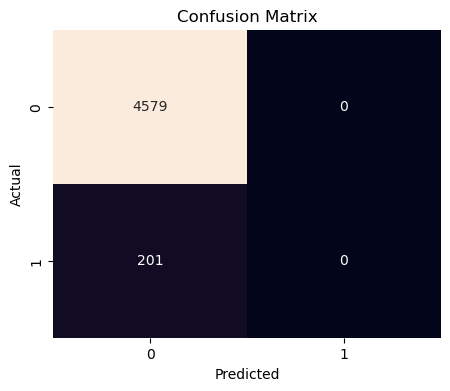

In [32]:
test_class = (test_pred >= 0.50).astype(int)

print("Accuracy:", round(accuracy_score(y_test, test_class), 4))
print("\nClassification report:")
print(classification_report(y_test, test_class))

cm = confusion_matrix(y_test, test_class)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 24. Feature importance by gain

In [33]:
# XGBoost's feature_importances_ is based on the model's configured
# importance measure. For an explicit gain table, use booster.get_score.
booster = model.get_booster()

gain_dict = booster.get_score(importance_type="gain")

feature_gain = pd.DataFrame({
    "feature": X_train.columns,
    "gain": [
        gain_dict.get(feature, 0.0)
        for feature in X_train.columns
    ]
})

feature_gain = (
    feature_gain
    .sort_values("gain", ascending=False)
    .reset_index(drop=True)
)

display(feature_gain.head(30))

,feature,gain
0,count_enquiry_recency_90,16.979176
1,count_enquiry_recency_365,15.129718
2,feature_7,14.947418
3,cashlimit_sum,14.710183
4,feature_52,14.495314
5,feature_53,13.266569
6,feature_51,12.968399
7,Ratio_currbalance_creditlimit,12.759521
8,feature_14,12.467055
9,max_freq_enquiry,11.788381


## 25. Plot top features

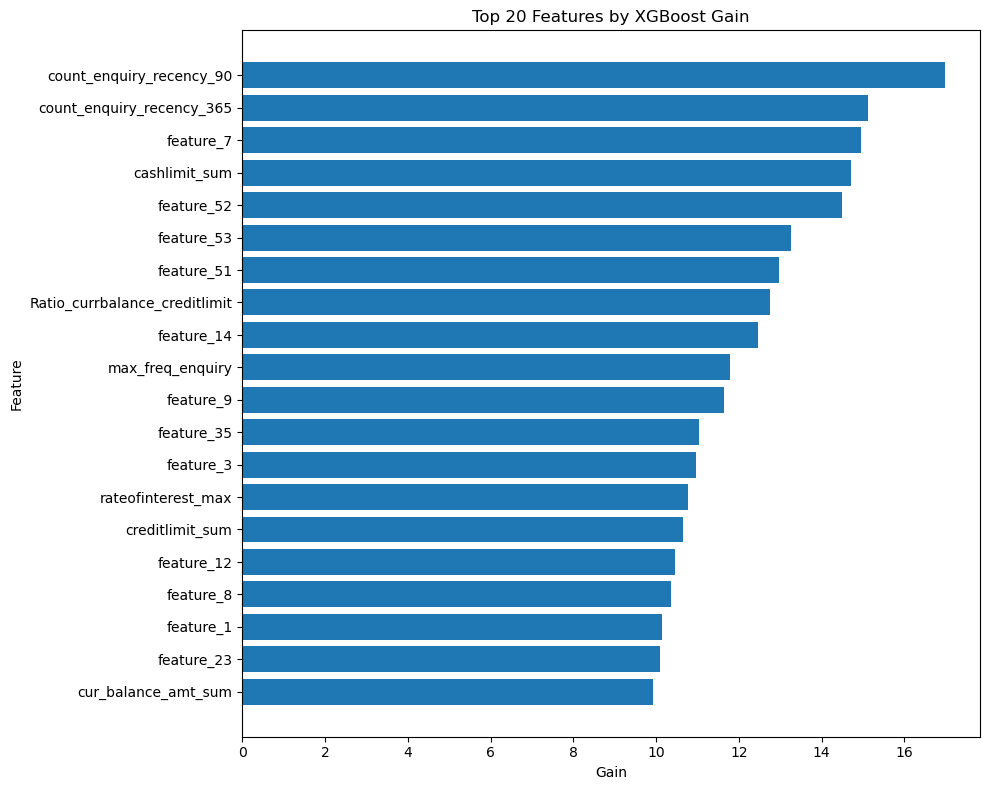

In [34]:
top_n = 20
top_features = feature_gain.head(top_n).sort_values("gain")

plt.figure(figsize=(10, 8))
plt.barh(top_features["feature"], top_features["gain"])
plt.title(f"Top {top_n} Features by XGBoost Gain")
plt.xlabel("Gain")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 26. Create test-set scoring table

In [35]:
rank_data = model_data.loc[
    X_test.index,
    [CUSTOMER_ID, TARGET]
].copy()

rank_data["predicted_probability"] = test_pred

rank_data = rank_data.sort_values(
    "predicted_probability",
    ascending=False
).reset_index(drop=True)

display(rank_data.head(10))

,customer_no,bad_label,predicted_probability
0,2461,0,0.296621
1,3406,0,0.249650
2,11620,0,0.232595
3,11821,0,0.231758
4,11321,0,0.222153
5,12908,0,0.221158
6,18896,0,0.219775
7,8583,0,0.219521
8,4827,0,0.212849
9,7230,0,0.212593


## 27. Decile rank ordering

In [36]:
# qcut creates approximately equal-sized groups.
# Highest probability gets the highest risk decile.
rank_data["decile_raw"] = pd.qcut(
    rank_data["predicted_probability"],
    q=10,
    labels=False,
    duplicates="drop"
)

rank_data["decile"] = (
    rank_data["decile_raw"].max() -
    rank_data["decile_raw"] + 1
).astype(int)

rank_data.drop(columns=["decile_raw"], inplace=True)

display(rank_data.head(20))

,customer_no,bad_label,predicted_probability,decile
0,2461,0,0.296621,1
1,3406,0,0.249650,1
2,11620,0,0.232595,1
3,11821,0,0.231758,1
4,11321,0,0.222153,1
5,12908,0,0.221158,1
6,18896,0,0.219775,1
7,8583,0,0.219521,1
8,4827,0,0.212849,1
9,7230,0,0.212593,1


## 28. Rank-ordering table

In [37]:
rank_ordering = (
    rank_data
    .groupby("decile")
    .agg(
        customers=(CUSTOMER_ID, "count"),
        bad_customers=(TARGET, "sum"),
        average_score=("predicted_probability", "mean"),
        minimum_score=("predicted_probability", "min"),
        maximum_score=("predicted_probability", "max")
    )
    .reset_index()
    .sort_values("decile", ascending=False)
)

rank_ordering["bad_rate_pct"] = (
    rank_ordering["bad_customers"] /
    rank_ordering["customers"] * 100
)

rank_ordering["population_pct"] = (
    rank_ordering["customers"] /
    rank_ordering["customers"].sum() * 100
)

rank_ordering["cumulative_bad_customers"] = (
    rank_ordering["bad_customers"].cumsum()
)

rank_ordering["cumulative_bad_capture_pct"] = (
    rank_ordering["cumulative_bad_customers"] /
    rank_ordering["bad_customers"].sum() * 100
)

display(rank_ordering.round(2))

,decile,customers,bad_customers,average_score,minimum_score,maximum_score,bad_rate_pct,population_pct,cumulative_bad_customers,cumulative_bad_capture_pct
9,10,478,3,0.01,0.00,0.01,0.63,10.0,3,1.49
8,9,478,7,0.02,0.01,0.02,1.46,10.0,10,4.98
7,8,478,10,0.02,0.02,0.02,2.09,10.0,20,9.95
6,7,478,11,0.02,0.02,0.03,2.30,10.0,31,15.42
5,6,478,19,0.03,0.03,0.03,3.97,10.0,50,24.88
4,5,478,27,0.04,0.03,0.04,5.65,10.0,77,38.31
3,4,478,24,0.04,0.04,0.05,5.02,10.0,101,50.25
2,3,478,27,0.05,0.05,0.06,5.65,10.0,128,63.68
1,2,478,28,0.07,0.06,0.08,5.86,10.0,156,77.61
0,1,478,45,0.11,0.08,0.30,9.41,10.0,201,100.00


## 29. Rank-ordering validation

In [38]:
# A useful first diagnostic: bad rate should generally be higher in
# the highest-risk deciles and lower in the lowest-risk deciles.

rank_check = rank_ordering[
    ["decile", "customers", "bad_customers", "bad_rate_pct",
     "cumulative_bad_capture_pct"]
].copy()

display(rank_check.round(2))

print(
    "\nHighest-risk decile bad rate:",
    round(rank_ordering.iloc[0]["bad_rate_pct"], 2), "%"
)

print(
    "Lowest-risk decile bad rate:",
    round(rank_ordering.iloc[-1]["bad_rate_pct"], 2), "%"
)

,decile,customers,bad_customers,bad_rate_pct,cumulative_bad_capture_pct
9,10,478,3,0.63,1.49
8,9,478,7,1.46,4.98
7,8,478,10,2.09,9.95
6,7,478,11,2.30,15.42
5,6,478,19,3.97,24.88
4,5,478,27,5.65,38.31
3,4,478,24,5.02,50.25
2,3,478,27,5.65,63.68
1,2,478,28,5.86,77.61
0,1,478,45,9.41,100.00



Highest-risk decile bad rate: 0.63 %
Lowest-risk decile bad rate: 9.41 %


## 30. Plot bad rate by decile

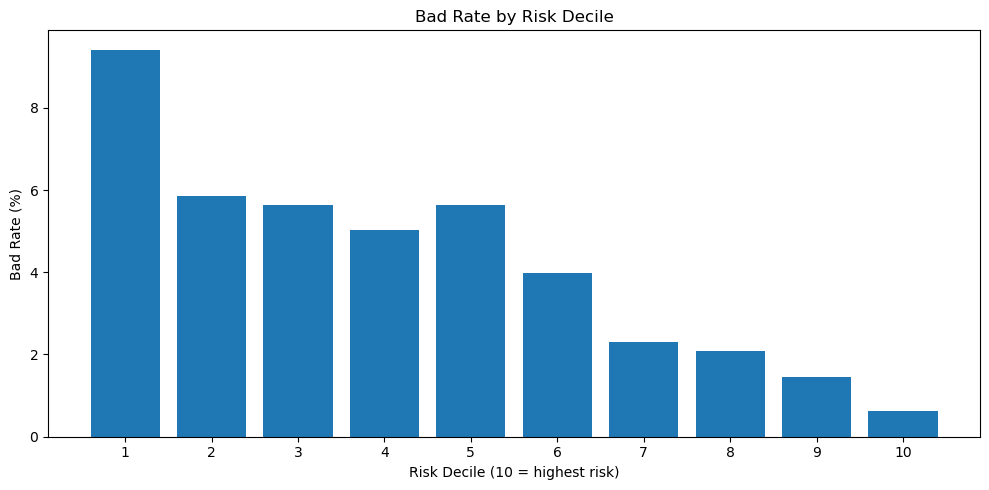

In [39]:
plot_data = rank_ordering.sort_values("decile")

plt.figure(figsize=(10,5))
plt.bar(
    plot_data["decile"].astype(str),
    plot_data["bad_rate_pct"]
)
plt.title("Bad Rate by Risk Decile")
plt.xlabel("Risk Decile (10 = highest risk)")
plt.ylabel("Bad Rate (%)")
plt.tight_layout()
plt.show()

## 31. Plot cumulative bad capture

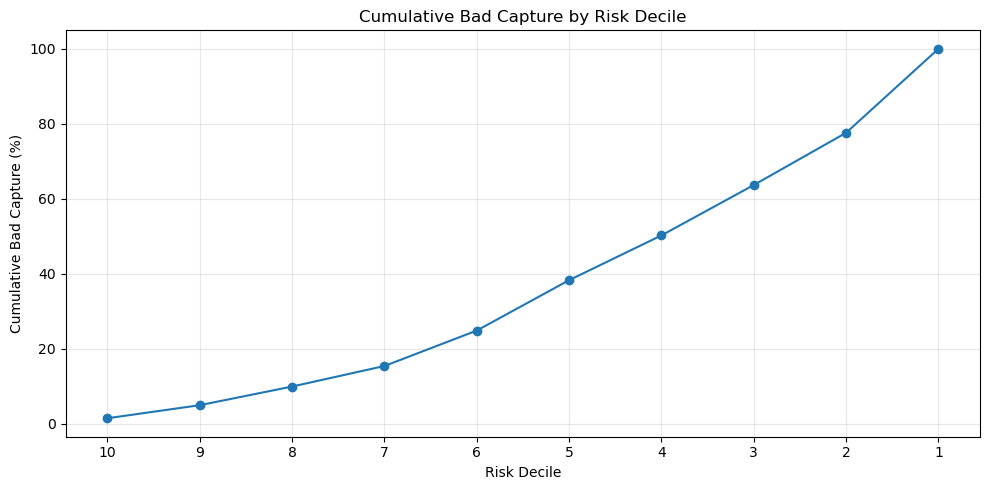

In [40]:
plot_data = rank_ordering.sort_values("decile", ascending=False)

plt.figure(figsize=(10,5))
plt.plot(
    plot_data["decile"].astype(str),
    plot_data["cumulative_bad_capture_pct"],
    marker="o"
)
plt.title("Cumulative Bad Capture by Risk Decile")
plt.xlabel("Risk Decile")
plt.ylabel("Cumulative Bad Capture (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 32. Optional KS statistic

In [41]:
def calculate_ks(y_true, probability):
    temp = pd.DataFrame({
        "y": np.asarray(y_true),
        "score": np.asarray(probability)
    }).sort_values("score", ascending=False)

    total_bad = (temp["y"] == 1).sum()
    total_good = (temp["y"] == 0).sum()

    if total_bad == 0 or total_good == 0:
        return np.nan

    temp["cum_bad"] = (temp["y"] == 1).cumsum() / total_bad
    temp["cum_good"] = (temp["y"] == 0).cumsum() / total_good

    return (temp["cum_bad"] - temp["cum_good"]).abs().max()

test_ks = calculate_ks(y_test, test_pred)

print(f"Test KS: {test_ks * 100:.2f}")

Test KS: 27.84


## 33. Export outputs

In [42]:
OUTPUT_DIR = "credit_risk_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

feature_gain.to_csv(
    os.path.join(OUTPUT_DIR, "feature_gain.csv"),
    index=False
)

rank_ordering.to_csv(
    os.path.join(OUTPUT_DIR, "rank_ordering.csv"),
    index=False
)

rank_data.to_csv(
    os.path.join(OUTPUT_DIR, "customer_predictions.csv"),
    index=False
)

performance.to_csv(
    os.path.join(OUTPUT_DIR, "model_performance.csv"),
    index=False
)

print(f"Outputs saved to: {OUTPUT_DIR}/")

Outputs saved to: credit_risk_outputs/


## 34. Final project summary

In [43]:
print("=" * 60)
print("BANK GOODCREDIT - CREDIT RISK MODEL SUMMARY")
print("=" * 60)

print(f"Number of modelling rows : {len(model_data):,}")
print(f"Number of input features: {X.shape[1]:,}")
print(f"Train AUC               : {train_auc:.4f}")
print(f"Test AUC                : {test_auc:.4f}")
print(f"Train Gini              : {train_gini * 100:.2f}")
print(f"Test Gini               : {test_gini * 100:.2f}")
print(f"Benchmark Gini          : {BENCHMARK_GINI:.2f}")
print(f"Test KS                 : {test_ks * 100:.2f}")
print("=" * 60)

if test_gini * 100 >= BENCHMARK_GINI:
    print("Conclusion: Test Gini meets/exceeds the project benchmark.")
else:
    print("Conclusion: Test Gini is below the project benchmark; further feature")
    print("engineering, validation and model tuning are required.")

print("\nTop 10 features by gain:")
display(feature_gain.head(10))

BANK GOODCREDIT - CREDIT RISK MODEL SUMMARY
Number of modelling rows : 23,896
Number of input features: 118
Train AUC               : 0.8773
Test AUC                : 0.6740
Train Gini              : 75.46
Test Gini               : 34.81
Benchmark Gini          : 37.90
Test KS                 : 27.84
Conclusion: Test Gini is below the project benchmark; further feature
engineering, validation and model tuning are required.

Top 10 features by gain:


,feature,gain
0,count_enquiry_recency_90,16.979176
1,count_enquiry_recency_365,15.129718
2,feature_7,14.947418
3,cashlimit_sum,14.710183
4,feature_52,14.495314
5,feature_53,13.266569
6,feature_51,12.968399
7,Ratio_currbalance_creditlimit,12.759521
8,feature_14,12.467055
9,max_freq_enquiry,11.788381


## 35. Important project notes

### Payment history
The project document lists `paymenthistory1` and `paymenthistory2`, and suggests a feature called `payment_history_avg_dpd_0_29_bucket`. However, the business-case document does not describe the exact encoding of those fields. The notebook therefore **does not guess their encoding**.

After inspecting the actual values, add a dedicated parser and validate it against the business definition.

### Utilisation trend
The project suggests a `utilisation_trend` feature. Its exact implementation depends on how account history is represented and what date/snapshot logic the source data supports. Do not assume a time-series calculation without inspecting the actual data.

### Validation
For a production-style credit-risk model, consider:
- out-of-time validation rather than only a random split
- leakage checks
- missing-value treatment based on train data only
- feature stability / PSI
- calibration
- business cut-offs
- reject inference where applicable
- explainability and governance

### Benchmark
The project benchmark is Gini = 37.9. Compare the test/out-of-time Gini against this benchmark rather than comparing training performance.